# 1.6 统计学基础与假设检验

> **这一节讲什么？**
> 
> 市场数据充满噪音。这一节教你用统计学工具判断一个规律是真实存在的"信号"，还是随机"噪音"——从概率分布、假设检验到相关性陷阱，这是所有量化研究的基石。

## 学习目标
- 理解随机变量与常见概率分布（正态、t 分布、胖尾）
- 掌握假设检验（t-test、p-value）在策略评估中的应用
- 识别相关性陷阱与伪回归问题
- 了解置信区间与统计显著性的实际意义

## 1. 随机变量与概率分布 (Random Variables & Probability Distributions)

金融资产的收益率通常被建模为**随机变量**。了解资产收益率的**概率分布**对于风险管理和策略评估至关重要。

### 正态分布 (Normal Distribution)

最经典的分布。它的特点是钟形曲线，由均值（均指望收益）和标准差（波动率）决定。
在传统金融理论中，由于中心极限定理，股票收益率常被假设为正态分布。


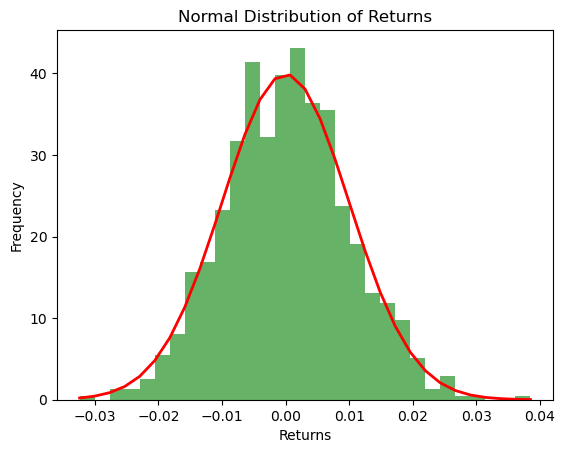

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 生成正态分布数据
mu, sigma = 0, 0.01 # 假设日均收益率为0，日波动率为1%
# 设置随机种子保证可重复性
np.random.seed(42)
s = np.random.normal(mu, sigma, 1000)

# 绘制直方图和概率密度分布图
count, bins, ignored = plt.hist(s, 30, density=True, alpha=0.6, color='g')
plt.plot(bins, 1/(sigma * np.sqrt(2 * np.pi)) * np.exp( - (bins - mu)**2 / (2 * sigma**2) ), linewidth=2, color='r')
plt.title('Normal Distribution of Returns')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.show()


In [2]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

### 肥尾效应 (Fat Tails / Leptokurtic)

**现实中的金融市场数据并不严格服从正态分布。** 它们通常呈现出“尖峰肥尾”的特征。这意味着极端事件（极端收益或极端亏损，即“黑天鹅”事件）发生的概率比正态分布预测的要高得多。

*   **偏度 (Skewness):** 衡量分布的非对称性。负偏度意味着大概率有小收益，但有小概率发生大额亏损。
*   **峰度 (Kurtosis):** 衡量分布尾部的厚度。正态分布的峰度是 3（超额峰度为 0）。真实的股票收益率通常具有正的超额峰度（肥尾）。

在量化建模时，忽视肥尾效应会导致对尾部风险（Tail Risk）的严重低估。


In [3]:
# 我们可以用 scipy.stats 来计算偏度和峰度
print(f'偏度 (Skewness): {stats.skew(s):.4f}')
print(f'峰度 (Kurtosis): {stats.kurtosis(s):.4f}')


偏度 (Skewness): 0.1168
峰度 (Kurtosis): 0.0662


## 2. 假设检验 (Hypothesis Testing) 与 P值 (P-Value)

当我们回测一个策略并得到正的历史收益时，我们如何知道这是否只是运气好？这就需要**假设检验**。

*   **原假设 (Null Hypothesis, $H_0$):** 通常是我们试图反驳的假设。例如：“这个策略的期望超额收益为0”（策略无效）。
*   **备择假设 (Alternative Hypothesis, $H_1$):** 我们试图证明的假设。例如：“这个策略的期望超额收益大于0”（策略有效）。

### P值 (P-Value)

P值是在原假设 ($H_0$) 成立的前提下，观察到当前数据（或更极端数据）的概率。

*   **P值越小，反驳原假设的证据就越强。**
*   通常使用的显著性水平（Significance Level, $\alpha$）是 5% (0.05) 或 1% (0.01)。
*   如果 P值 < $\alpha$，我们**拒绝原假设**，认为策略“在统计上显著”地赚钱。

**注意：** P值 < 0.05 并不意味着策略有 95% 的概率赚钱。它只意味着，如果策略实际上不赚钱，你能在回测中看到这么好（或更好）结果的概率不到 5%。这是量化研究中常见的误区。


In [4]:
# T检验示例：检验平均收益率是否显著不为0
# 假设我们有一组策略回测的每日收益率
strategy_returns = np.random.normal(0.0005, 0.01, 252)  # 均值为正

t_stat, p_val = stats.ttest_1samp(strategy_returns, 0.0)
print(f'T-statistic: {t_stat:.4f}')
print(f'P-value: {p_val:.4f}')

if p_val < 0.05:
    print('拒绝原假设：策略日均收益显著不为0')
else:
    print('不能拒绝原假设：无法说明策略赚钱')


T-statistic: 2.5611
P-value: 0.0110
拒绝原假设：策略日均收益显著不为0


## 3. 多重比较偏差 (Multiple Testing Bias)

在量化研究中，我们经常测试成百上千个参数或因子。如果我们使用 5% 的显著性水平，即使所有策略都是随机的（无效的），也有大约 5% 的策略会因为运气而显得“显著有效”。

这就是**多重比较偏差**，也称为**数据挖掘偏差 (Data Mining Bias)** 或 P-hacking。为了避免将随机噪音误认为是真实信号，我们需要对显著性水平进行调整，例如使用 Bonferroni 校正或 FDR (False Discovery Rate) 控制。

在后续的机器学习章节中，我们将介绍**Purged K-Fold Cross-Validation** 作为应对过拟合的重要手段。


## 4. 相关性：Pearson vs Spearman (Correlation)

在上面提到了相关性，量化中最常提到两种相关系数：

*   **Pearson 相关系数 (皮尔逊)**: 衡量两个连续变量之间的**线性关系**强度。它对极值（Outliers）非常敏感。
*   **Spearman 秩相关系数 (斯皮尔曼)**: 衡量两个变量的**单调关系**。它不是直接基于具体数值算，而是先把数值转为排名（Rank），再计算排名的相关性。这使得它对极值非常鲁棒，并且能捕捉非线性的单调关系。

**重要应用：**由于金融收益率具有严重的肥尾且常常有异常极值，在用前文提到的 `Alphalens` 计算信息系数（IC）时，我们几乎总是使用 **Spearman Rank Correlation**，而不是普通的 Pearson。


In [5]:
import scipy.stats as stats
import numpy as np

# 模拟包含极端异常值的数据
np.random.seed(42)
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y = np.array([1.2, 2.1, 2.9, 4.2, 5.1, 5.8, 7.2, 8.1, 9.5, 100.0]) # 最后一个是极值

pearson_corr, _ = stats.pearsonr(x, y)
spearman_corr, _ = stats.spearmanr(x, y)

print(f"Pearson 相关 (受极值影响): {pearson_corr:.4f}")
print(f"Spearman 秩相关 (鲁棒): {spearman_corr:.4f}")


Pearson 相关 (受极值影响): 0.5950
Spearman 秩相关 (鲁棒): 1.0000


## 5. 线性回归与 Beta ($\beta$) 的估计 (Linear Regression)

线性回归是最基础也是运用最广的统计模型，比如计算一只股票相对于大盘的 Beta（即著名的 CAPM 模型中的市场风险暴露）。

公式：$Y = \alpha + \beta X + \epsilon$
*   $Y$ 是一只股票的日收益率。
*   $X$ 是大盘指数的日收益率。
*   $\alpha$ (Alpha) 是截距，代表股票超额（独立于大盘）的收益表现。
*   $\beta$ (Beta) 是斜率，代表这只股票相对于大盘变动的敏感度。

普通最小二乘法 (OLS) 是最常用的求解方式。


回归结果摘要:
Alpha (截距): 0.000624 | P-Value: 0.0495
Beta (市场斜率): 1.211484 | P-Value: 0.0000
R-Squared (解释率): 0.8454


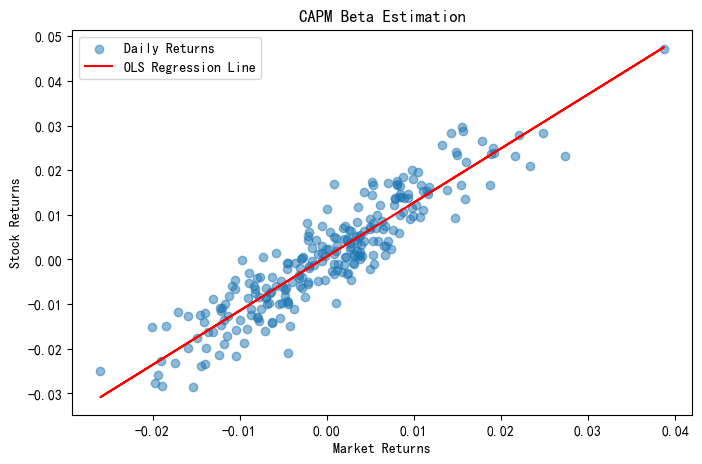

In [6]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 假设 X 是市场收益率，Y 是某只股票收益率
np.random.seed(42)
market_returns = np.random.normal(0.0002, 0.01, 252)
# 假设该股票的真实 Beta 是 1.2，真实 Alpha 是 0.0005
stock_returns = 0.0005 + 1.2 * market_returns + np.random.normal(0, 0.005, 252)

# 使用 statsmodels 进行 OLS 回归
# 注意需要手动加上一列常数项 (1) 以便拟合截距 alpha
X_with_constant = sm.add_constant(market_returns)

model = sm.OLS(stock_returns, X_with_constant)
results = model.fit()

print("回归结果摘要:")
print(f"Alpha (截距): {results.params[0]:.6f} | P-Value: {results.pvalues[0]:.4f}")
print(f"Beta (市场斜率): {results.params[1]:.6f} | P-Value: {results.pvalues[1]:.4f}")
print(f"R-Squared (解释率): {results.rsquared:.4f}")

# 画出拟合散点图和回归线
plt.figure(figsize=(8, 5))
plt.scatter(market_returns, stock_returns, alpha=0.5, label='Daily Returns')
plt.plot(market_returns, results.predict(X_with_constant), color='red', label='OLS Regression Line')
plt.xlabel('Market Returns')
plt.ylabel('Stock Returns')
plt.title('CAPM Beta Estimation')
plt.legend()
plt.show()


## 🎯 练习

1. 将代码中的 `strategy_returns` 换成真实 AAPL 的日收益率，对其平均收益进行 t 检验，看是否显著大于 0。
2. 查阅 Bonferroni 校正，对 100 个随机策略同时进行假设检验，多少个会因为多重比较偏差误判为显著？
3. 比较 `stats.pearsonr` 和 `stats.spearmanr` 在有异常值时的鲁棒性差异（用 SPY 真实数据）。

---
**下一节** → `07_time_series_analysis.ipynb`
